In [1]:
import sys
sys.path.append('/home/xinyiz/c2p_dag/')
sys.path.append('/home/xinyiz/c2p_dag/img2seq/')

import numpy as np
import pickle
import os
import pandas as pd
from scipy import sparse

import time

import scanpy
import numpy as np

import torch
from torch import optim


import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import anndata as ad
import gc


import gae.gae.optimizer as optimizer

import gae.gae.model
import gae.gae.model_lord
import gae.gae.preprocessing as preprocessing

2025-05-27 16:28:28.688822: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
nSamples= 2048

Z1 = np.random.binomial(1, 0.5, size=nSamples)

gamma2 = np.random.gamma(shape=5, scale=1, size=nSamples)
Z2 = Z1 + gamma2 * np.sqrt(0.0045) 

Z3 = np.random.binomial(1, 0.5, size=nSamples)

gamma4 = np.random.gamma(shape=2, scale=2, size=nSamples)
Z4 = 2 * Z2 + Z3 + gamma4 * np.sqrt(0.00125)

gamma5 = np.random.gamma(shape=3, scale=2, size=nSamples)
Z5 = Z2 + gamma5 * np.sqrt(0.0075)

Z = np.stack([Z1, Z2, Z3, Z4, Z5], axis=1)

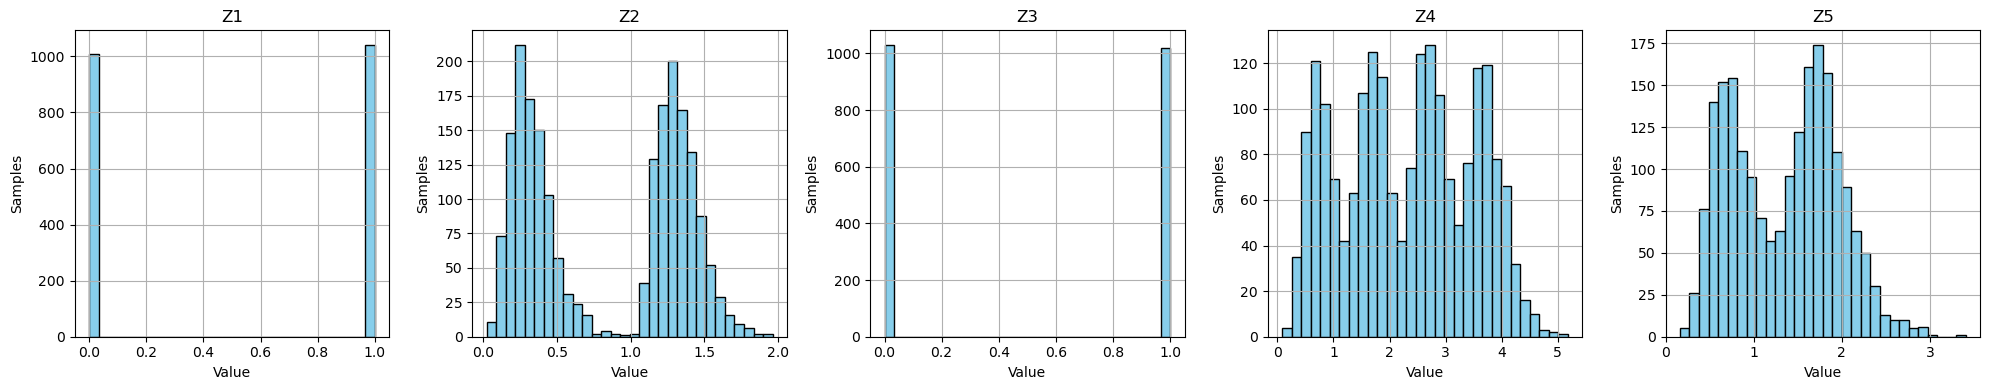

In [3]:
variables = [Z1, Z2, Z3, Z4, Z5]
titles = ['Z1', 'Z2', 'Z3', 'Z4', 'Z5']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, (z, title) in enumerate(zip(variables, titles)):
    axs[i].hist(z, bins=30, color='skyblue', edgecolor='black')
    axs[i].set_title(title)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Samples')
    axs[i].grid(True)

plt.tight_layout()
plt.savefig('z_distribution_mixingL_indeptObs.pdf')
plt.show()

In [4]:
Z

array([[0.        , 0.17305865, 0.        , 0.55394954, 0.74338267],
       [0.        , 0.27999538, 1.        , 1.83499504, 1.01020525],
       [0.        , 0.1744532 , 0.        , 0.39034679, 0.34041858],
       ...,
       [1.        , 1.62996279, 0.        , 3.29476365, 2.38226123],
       [1.        , 1.64484316, 1.        , 4.41251213, 1.95634286],
       [0.        , 0.28734705, 1.        , 1.67171456, 0.9425699 ]])

In [5]:
X = np.zeros((nSamples, 40))

Z_X = np.stack([Z1, Z2, Z3, Z4], axis=1)

# X1-X10: pure children of Z4
G1 = np.random.randn(10, 1)
X[:, 0:10] = Z_X[:, [3]] @ G1.T

# X11-X20: pure children of Z3
G2 = np.random.randn(10, 1)
X[:, 10:20] = Z_X[:, [2]] @ G2.T

# X21-X30: pure children of Z2
G3 = np.random.randn(10, 1)
X[:, 20:30] = Z_X[:, [1]] @ G3.T

# X31-X40: children of Z2 and Z3
G4 = np.random.randn(10, 1)
X[:, 30:40] = Z_X[:, [0]] @ G4.T

Y = np.zeros((nSamples, 30))

Z_Y = np.stack([Z1, Z2, Z5], axis=1)

GY1 = np.random.randn(10, 1)
Y[:, 0:10] = Z_Y[:, [2]] @ GY1.T

GY2 = np.random.randn(10, 1)
Y[:, 10:20] = Z_Y[:, [1]] @ GY2.T

GY3 = np.random.randn(10, 1)
Y[:, 20:30] = Z_Y[:, [0]] @ GY3.T



In [6]:
#train-test split
np.random.seed(3)
pctVal=0.05
pctTest=0.1

allIdx_all=np.arange(nSamples)
np.random.shuffle(allIdx_all)
valIdx_all=allIdx_all[:int(pctVal*nSamples)]
testIdx_all=allIdx_all[int(pctVal*nSamples):(int(pctVal*nSamples)+int(pctTest*nSamples))]
trainIdx_all=allIdx_all[(int(pctVal*nSamples)+int(pctTest*nSamples)):]

hiddenSize=20
sharedSize=2
dSpecificSize=2
seed=3
#test0: 5, 3

In [7]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
 

batchsize=256
saveFreq=100
epochs=3000
lr_latent=0.001
lr_decoder=0.0001
weight_decay=0

dropout=0.01
XreconWeight=20
ridgeL=0.01

addNoise=True
actDecay=0.001

testSaveName='lord_bce'
name='test4_noSharedRecon_mixingL_indeptObs'
logsavepath=os.path.join('/data/xinyi/c2p/simulation/results/log',testSaveName,name)
modelsavepath=os.path.join('/data/xinyi/c2p/simulation/results/models',testSaveName,name)
plotsavepath=os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName,name)

loss_x=torch.nn.MSELoss()
loss_y=torch.nn.MSELoss()

In [8]:
if not os.path.exists(os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName)):
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName))
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/models',testSaveName))
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/log',testSaveName))
if not os.path.exists(logsavepath):
    os.mkdir(logsavepath)
if not os.path.exists(modelsavepath):
    os.mkdir(modelsavepath)
if not os.path.exists(plotsavepath):
    os.mkdir(plotsavepath)
nFeatures_x=X.shape[1]
nFeatures_y=Y.shape[1]

In [9]:
def train(epoch):
    t = time.time()
    model_x.train()
    model_y.train()
    
    loss_all=0
    loss_x_train_all_x=0
    loss_x_train_all_y=0
    loss_lNorm_all=0
    loss_lNorm_all_x=0
    loss_lNorm_all_y=0
    
    ntrainBatches=int(np.ceil(trainIdx_all.shape[0]/batchsize))
    for i in range(ntrainBatches):
#         if i%200==0:
#             print(i)
        trainIdx=trainIdx_all[i*batchsize:min((i+1)*batchsize,trainIdx_all.shape[0])]
        traintarget_x=torch.tensor(X[trainIdx]).cuda().float()
        traintarget_y=torch.tensor(Y[trainIdx]).cuda().float()
        trainIdx=torch.tensor(trainIdx)
        trainInput_shared=latent_shared(trainIdx).cuda().float()
        trainInput_x=latent_x(trainIdx).cuda().float()
        trainInput_y=latent_y(trainIdx).cuda().float()

        if addNoise:
            trainInput_shared=trainInput_shared+torch.randn_like(trainInput_shared)
            trainInput_x=trainInput_x+torch.randn_like(trainInput_x)
            trainInput_y=trainInput_y+torch.randn_like(trainInput_y)
            
        optimizer_x.zero_grad()
        optimizer_latent.zero_grad()
        optimizer_y.zero_grad()

        recon_x= model_x(torch.cat((trainInput_shared,trainInput_x),dim=1))
        y_recon = model_y(torch.cat((trainInput_shared,trainInput_y),dim=1))

        loss_x_train_x=loss_x(recon_x, traintarget_x)
        loss_x_train_y=loss_y(y_recon, traintarget_y)        
        loss=loss_x_train_x+loss_x_train_y
        
        if addNoise:
            loss_lNorm=torch.mean(torch.linalg.norm(latent_shared(trainIdx).cuda(),dim=1))/latent_shared.embedding_dim
            loss_lNorm_all+=loss_lNorm.item()
            loss+=loss_lNorm*actDecay
            
            loss_lNorm_x=torch.mean(torch.linalg.norm(latent_x(trainIdx).cuda(),dim=1))/latent_x.embedding_dim
            loss_lNorm_all_x+=loss_lNorm_x.item()
            loss+=loss_lNorm_x*actDecay
            
            loss_lNorm_y=torch.mean(torch.linalg.norm(latent_y(trainIdx).cuda(),dim=1))/latent_y.embedding_dim
            loss_lNorm_all_y+=loss_lNorm_y.item()
            loss+=loss_lNorm_y*actDecay
            
        
        loss_x_train_all_y+=loss_x_train_y.item()
        loss_x_train_all_x+=loss_x_train_x.item()
        loss_all+=loss.item()
        
            
        loss.backward()
        optimizer_x.step()
        optimizer_latent.step()
        optimizer_y.step()


    loss_x_train_all_y=loss_x_train_all_y/ntrainBatches
    loss_x_train_all_x=loss_x_train_all_x/ntrainBatches
    loss_all=loss_all/ntrainBatches
    if addNoise:
        loss_lNorm_all=loss_lNorm_all/ntrainBatches
        loss_lNorm_all_x=loss_lNorm_all_x/ntrainBatches
        loss_lNorm_all_y=loss_lNorm_all_y/ntrainBatches

    
    with torch.no_grad():
        model_x.eval()
        model_y.eval()
        loss_x_val_all_x=0
        loss_x_val_all_y=0
        loss_val_all=0
        nvalBatches=int(np.ceil(valIdx_all.shape[0]/batchsize))
        for i in range(nvalBatches):
            valIdx=valIdx_all[i*batchsize:min((i+1)*batchsize,valIdx_all.shape[0])]
            valtarget_x=torch.tensor(X[valIdx]).cuda().float()
            valtarget_y=torch.tensor(Y[valIdx]).cuda().float()
            valIdx=torch.tensor(valIdx)
            valInput_shared=latent_shared(valIdx).cuda().float()
            valInput_x=latent_x(valIdx).cuda().float()
            valInput_y=latent_y(valIdx).cuda().float()

            recon_x= model_x(torch.cat((valInput_shared,valInput_x),dim=1))
            y_recon = model_y(torch.cat((valInput_shared,valInput_y),dim=1))

            loss_x_val_x=loss_x(recon_x, valtarget_x)
            loss_x_val_y=loss_y(y_recon, valtarget_y)


            loss=loss_x_val_x+loss_x_val_y
            
            loss_x_val_all_x+=loss_x_val_x.item()
            loss_x_val_all_y+=loss_x_val_y.item()
            loss_val_all+=loss.item()

        loss_x_val_all_x=loss_x_val_all_x/nvalBatches
        loss_x_val_all_y=loss_x_val_all_y/nvalBatches
        loss_val_all=loss_val_all/nvalBatches
    
    print(' Epoch: {:04d}'.format(epoch),
          'loss_train: {:.4f}'.format(loss_all),
          'loss_x_train_x: {:.4f}'.format(loss_x_train_all_x),
          'loss_x_train_y: {:.4f}'.format(loss_x_train_all_y),
          'loss_val: {:.4f}'.format(loss_val_all),
          'loss_x_val_x: {:.4f}'.format(loss_x_val_all_x),
          'loss_x_val_y: {:.4f}'.format(loss_x_val_all_y),
          'time: {:.4f}s'.format(time.time() - t))
    return loss_all,loss_x_train_all_x,loss_x_train_all_y,loss_val_all,loss_x_val_all_x,loss_x_val_all_y,loss_lNorm_all,loss_lNorm_all_x,loss_lNorm_all_y




In [10]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.enabled = True

model_x = gae.gae.model_lord.fc_decode_l4(nFeatures_x,sharedSize+dSpecificSize,hiddenSize, dropout)
model_y = gae.gae.model_lord.fc_decode_l4(nFeatures_y, sharedSize+dSpecificSize,hiddenSize, dropout)


model_x.cuda()
model_y.cuda()

optimizer_x = optim.Adam(model_x.parameters(), lr=lr_decoder, weight_decay=weight_decay)
optimizer_y = optim.Adam(model_y.parameters(), lr=lr_decoder, weight_decay=weight_decay)

latent_shared=torch.nn.Embedding(X.shape[0],sharedSize)
latent_x=torch.nn.Embedding(X.shape[0],dSpecificSize)
latent_y=torch.nn.Embedding(X.shape[0],dSpecificSize)
optimizer_latent= torch.optim.Adam([latent_shared.weight,latent_x.weight,latent_y.weight], lr=lr_latent, weight_decay=weight_decay)

train_loss=[np.inf]*(epochs)
val_loss=[np.inf]*(epochs)

train_loss_x=[np.inf]*(epochs)
val_loss_x=[np.inf]*(epochs)

train_loss_y=[np.inf]*(epochs)
val_loss_y=[np.inf]*(epochs)

train_lNorm=[np.inf]*(epochs)
train_lNorm_x=[np.inf]*(epochs)
train_lNorm_y=[np.inf]*(epochs)

t_ep=time.time()

for ep in range(epochs):

    train_loss[ep],train_loss_x[ep],train_loss_y[ep],val_loss[ep],val_loss_x[ep],val_loss_y[ep],train_lNorm[ep],train_lNorm_x[ep],train_lNorm_y[ep]=train(ep)


    if ep%saveFreq == 0 and ep != 0:
        torch.save(model_x.cpu().state_dict(), os.path.join(modelsavepath,str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)+'_x.pt'))
        torch.save(model_y.cpu().state_dict(), os.path.join(modelsavepath,str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)+'_y.pt'))

        with open(os.path.join(modelsavepath,'latentx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_x.weight, output, pickle.HIGHEST_PROTOCOL)
        with open(os.path.join(modelsavepath,'latentShared_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_shared.weight, output, pickle.HIGHEST_PROTOCOL)
        with open(os.path.join(modelsavepath,'latenty_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_y.weight, output, pickle.HIGHEST_PROTOCOL)



    model_x.cuda()
    model_y.cuda()
    torch.cuda.empty_cache()
print(' total time: {:.4f}s'.format(time.time() - t_ep))





 Epoch: 0000 loss_train: 2.8778 loss_x_train_x: 1.7751 loss_x_train_y: 1.1008 loss_val: 2.3219 loss_x_val_x: 1.4477 loss_x_val_y: 0.8741 time: 0.7276s
 Epoch: 0001 loss_train: 2.8580 loss_x_train_x: 1.7658 loss_x_train_y: 1.0903 loss_val: 2.3553 loss_x_val_x: 1.4760 loss_x_val_y: 0.8792 time: 0.0549s
 Epoch: 0002 loss_train: 2.8329 loss_x_train_x: 1.7529 loss_x_train_y: 1.0781 loss_val: 2.4014 loss_x_val_x: 1.5104 loss_x_val_y: 0.8910 time: 0.0524s
 Epoch: 0003 loss_train: 2.8095 loss_x_train_x: 1.7403 loss_x_train_y: 1.0673 loss_val: 2.4500 loss_x_val_x: 1.5438 loss_x_val_y: 0.9062 time: 0.0535s
 Epoch: 0004 loss_train: 2.7857 loss_x_train_x: 1.7269 loss_x_train_y: 1.0570 loss_val: 2.4869 loss_x_val_x: 1.5683 loss_x_val_y: 0.9186 time: 0.0639s
 Epoch: 0005 loss_train: 2.7634 loss_x_train_x: 1.7140 loss_x_train_y: 1.0476 loss_val: 2.5090 loss_x_val_x: 1.5826 loss_x_val_y: 0.9264 time: 0.0560s
 Epoch: 0006 loss_train: 2.7498 loss_x_train_x: 1.7079 loss_x_train_y: 1.0400 loss_val: 2.5159

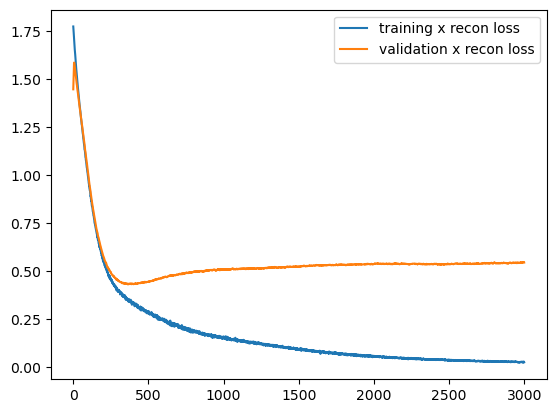

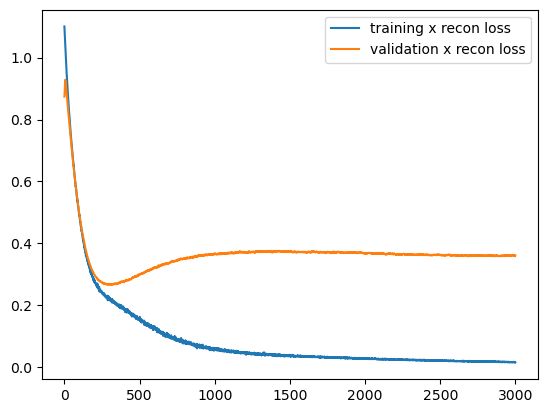

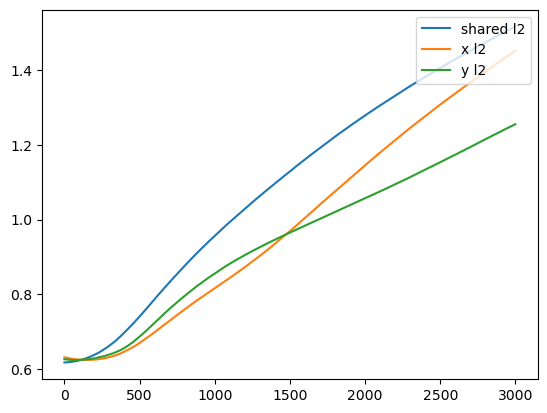

In [11]:
with open(os.path.join(logsavepath,'train_loss_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_loss_x_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_x_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_loss_y_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss_y, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_y_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss_y, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNorm_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNormx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNormy_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm_y, output, pickle.HIGHEST_PROTOCOL)



plt.plot(np.arange(epochs),train_loss_x)
plt.plot(np.arange(epochs),val_loss_x)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['training x recon loss','validation x recon loss','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_x'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()



plt.plot(np.arange(epochs),train_loss_y)
plt.plot(np.arange(epochs),val_loss_y)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['training x recon loss','validation x recon loss','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_y'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()


plt.plot(np.arange(epochs),train_lNorm)
plt.plot(np.arange(epochs),train_lNorm_x)
plt.plot(np.arange(epochs),train_lNorm_y)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['shared l2','x l2','y l2'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_lNorm'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()



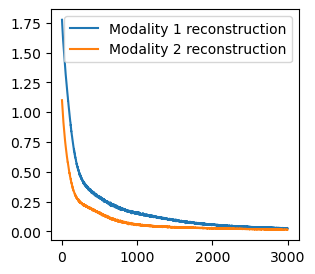

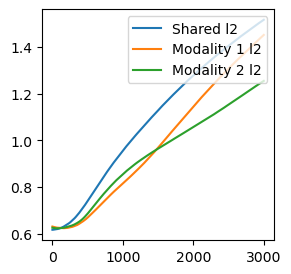

In [29]:
fig, ax = plt.subplots(figsize=(3.2,3))
plt.plot(np.arange(epochs),train_loss_x)
plt.plot(np.arange(epochs),train_loss_y)
plt.legend(['Modality 1 reconstruction','Modality 2 reconstruction','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'fig_loss_xy'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.pdf'))
plt.show()

fig, ax = plt.subplots(figsize=(3,3))
plt.plot(np.arange(epochs),train_lNorm)
plt.plot(np.arange(epochs),train_lNorm_x)
plt.plot(np.arange(epochs),train_lNorm_y)
plt.legend(['Shared l2','Modality 1 l2','Modality 2 l2'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'fig_loss_lNorm'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.pdf'))
plt.show()



In [12]:
latent_shared=torch.nn.Embedding(X.shape[0],sharedSize)
latent_x=torch.nn.Embedding(X.shape[0],dSpecificSize)
latent_y=torch.nn.Embedding(X.shape[0],dSpecificSize)

loadEpoch='2900'
with open(os.path.join(modelsavepath,'latentx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_x.weight=pickle.load(output)
with open(os.path.join(modelsavepath,'latentShared_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_shared.weight=pickle.load( output)
with open(os.path.join(modelsavepath,'latenty_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_y.weight=pickle.load(output)
latent_x.weight.requires_grad=False
latent_shared.weight.requires_grad=False
latent_y.weight.requires_grad=False


In [13]:
n_neighbors=10
min_dist=0.25

reducer_sharedlatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_shared.weight[trainIdx_all].cpu().detach())

In [14]:
def plotembeddingbyCT(ctlist,savename,excludelist,embedding,savepath,plotname,plotdimx=0,plotdimy=1,savenameAdd='',img=None,ncolors=None,colorseq=None,s=2.5):
    
    celltypes=np.unique(ctlist)
    if ncolors is None:
        colortest=sns.color_palette("husl", celltypes.size)
        if colorseq is None:
            colorseq=np.arange(celltypes.size)
    else:
        colortest=sns.color_palette("husl", ncolors)
        if colorseq is None:
            colorseq=np.arange(ncolors)

    
    fig, ax = plt.subplots(dpi=400)
    if not img is None:
        plt.imshow(img)
    for ct in celltypes:
        if ct in excludelist:
            continue
        idx=(ctlist==ct)
        if not img is None:
            ax.scatter(
                embedding[idx, plotdimy],
                embedding[idx, plotdimx],
                color=colortest[colorseq[int(ct)]],label=ct,s=1.5,alpha=0.5
                )
        else:
            ax.scatter(
                embedding[idx, plotdimx],
                embedding[idx, plotdimy],
                color=colortest[colorseq[int(ct)]],label=ct,s=s,alpha=1
                )

    plt.gca().set_aspect('equal', 'datalim')
    fig.set_figheight(5)
    fig.set_figwidth(5)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1,
                     box.width, box.height * 0.9])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
              fancybox=True,ncol=5, shadow=True,prop={'size': 6})
    plt.title(plotname+' embedding', fontsize=12)
    plt.savefig(os.path.join(savepath,savename+savenameAdd+'.pdf'))
    plt.close('all')
    
def plotembeddingbyCT_str(ctlist,savename,excludelist,embedding,savepath,plotname,plotdimx=0,plotdimy=1,savenameAdd=''):
    celltypes=np.unique(ctlist)
    celltypes_dict={}
    idx=0
    for ct in celltypes:
        celltypes_dict[ct]=idx
        idx+=1
        
    colortest=sns.color_palette("husl", celltypes.size)
    fig, ax = plt.subplots(dpi=400)
    for ct in celltypes:
        if ct in excludelist:
            continue
        idx=(ctlist==ct)
        ax.scatter(
            embedding[idx, plotdimx],
            embedding[idx, plotdimy],
            color=colortest[celltypes_dict[ct]],label=ct,s=1,alpha=0.5
            )

    plt.gca().set_aspect('equal', 'datalim')
    fig.set_figheight(6)
    fig.set_figwidth(6)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.3,
                     box.width, box.height * 0.7])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
              fancybox=True, ncol=3, shadow=True, prop={'size': 6})
    plt.title(plotname, fontsize=12)
    plt.savefig(os.path.join(savepath,savename+savenameAdd+'.pdf'))
    
    plt.close('all')
    
    gc.collect()

In [15]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_shared_latent',[],reducer_sharedlatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [16]:
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_shared_latent',[],reducer_sharedlatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [17]:
reducer_ylatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_y.weight[trainIdx_all].cpu().detach())

In [18]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_Y_latent',[],reducer_ylatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_Y_latent',[],reducer_ylatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [19]:
reducer_xlatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_x.weight[trainIdx_all].cpu().detach())

In [20]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_X_latent',[],reducer_xlatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_X_latent',[],reducer_xlatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [21]:
from sklearn.metrics import silhouette_score

In [22]:
silhouette_score(latent_shared.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.6971395

In [23]:
silhouette_score(latent_shared.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

0.026219154

In [24]:
silhouette_score(latent_x.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

0.41347787

In [25]:
silhouette_score(latent_x.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.19412951

In [26]:
silhouette_score(latent_y.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.45180637

In [27]:
silhouette_score(latent_y.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

-0.0004673883